# 04 — SHAP Analysis

Day 4: explain the trained model's predictions with SHAP (SHapley Additive exPlanations)
— which features push a given SA2's predicted heat up or down, and by how much. See
`DAY_4.md` for the concept explanation (what a Shapley value actually is) and the full
write-up.

This notebook loads the saved `models/best_model.joblib` directly, so what's explained
here is exactly the model that would be used downstream (e.g. in the Day 6/7 dashboard),
not a separate copy. This notebook runs entirely locally against the project's `.venv`.
Select the **Python (urbancool-melbourne)** kernel in VS Code.

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / "pyproject.toml").exists():
            return parent
    raise RuntimeError("Could not find project root (no pyproject.toml found in any parent)")


PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

Project root: F:\personal_documents\Study\urbancool_melbourne\urbancool_melbourne


In [2]:
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from src.data.loaders import load_config
from src.models.train import FEATURE_COLS, TARGET_COL, load_model_data

warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "text.color": "#0b0b0b",
    "font.size": 10,
})

BLUE = "#2a78d6"
GREEN = "#008300"


## 1. Load the saved model and data

The saved pipeline (`models/best_model.joblib`) was **refit on all 353 SA2 rows** (train +
test) using the hyperparameters selected in `03_model_training.ipynb` — that notebook
already answered "how well does this generalise to unseen areas" with a proper held-out
test set, so there's no need to hold out data again here. SHAP below explains this
production model's behaviour across the full Greater Melbourne population it was
ultimately fit on.

In [3]:
config = load_config()
model = joblib.load(PROJECT_ROOT / config["paths"]["models"] / "best_model.joblib")
model_name = type(model.named_steps["model"]).__name__
print("Loaded pipeline steps:", list(model.named_steps.keys()))
print("Underlying model:", model_name)

data = load_model_data(config)
X = data[FEATURE_COLS]

# SHAP's TreeExplainer works on the raw tree model, not the sklearn Pipeline wrapper, so
# we replay the pipeline's own imputer (fit on the same data at training time) to get the
# exact matrix the model actually sees, then re-attach feature names for readable plots.
X_imputed = pd.DataFrame(model.named_steps["impute"].transform(X), columns=FEATURE_COLS, index=X.index)
X_imputed.shape

2026-07-09 00:30:53,380 INFO Loaded 361 SA2 rows, dropped 8 with no heat target -> 353 modeling rows


Loaded pipeline steps: ['impute', 'model']
Underlying model: RandomForestRegressor


(353, 12)

## 2. Compute SHAP values

`TreeExplainer` computes *exact* Shapley values for tree ensembles (no sampling
approximation needed, unlike the general-purpose `KernelExplainer`) by walking the trees'
decision paths directly — see `DAY_4.md` for what a Shapley value means. Each SA2 gets
one SHAP value per feature; they sum to that SA2's prediction minus the average
prediction across all SA2s.

In [4]:
explainer = shap.TreeExplainer(model.named_steps["model"])
explanation = explainer(X_imputed)

print("shap values shape:", explanation.values.shape)
print("base value (average predicted UHI across all SA2s):", round(explanation.base_values[0], 3))
print("actual mean of predictions:", round(model.predict(X).mean(), 3))

# Sanity check: base_value + sum(shap values) must reconstruct the model's own prediction
# for every row, to float precision — if this fails, something is wrong with the setup above.
reconstructed = explanation.base_values + explanation.values.sum(axis=1)
actual_preds = model.predict(X)
max_diff = np.abs(reconstructed - actual_preds).max()
print("max |reconstructed - actual prediction| across all rows:", max_diff)
assert max_diff < 1e-6, "SHAP values do not reconstruct model predictions — explainer/data mismatch"


shap values shape: (353, 12)
base value (average predicted UHI across all SA2s): 8.218
actual mean of predictions: 8.226
max |reconstructed - actual prediction| across all rows: 1.9539925233402755e-14


## 3. Summary plot — which features matter, and which direction?

The classic SHAP beeswarm: each dot is one SA2. Position on the x-axis is that feature's
SHAP value (how much it pushed *this SA2's* prediction up or down from the average); dot
colour is the feature's own value (red = high, blue = low) using SHAP's standard colour
convention, not this project's chart palette — kept as-is since it's the widely
recognised default that SHAP users expect.

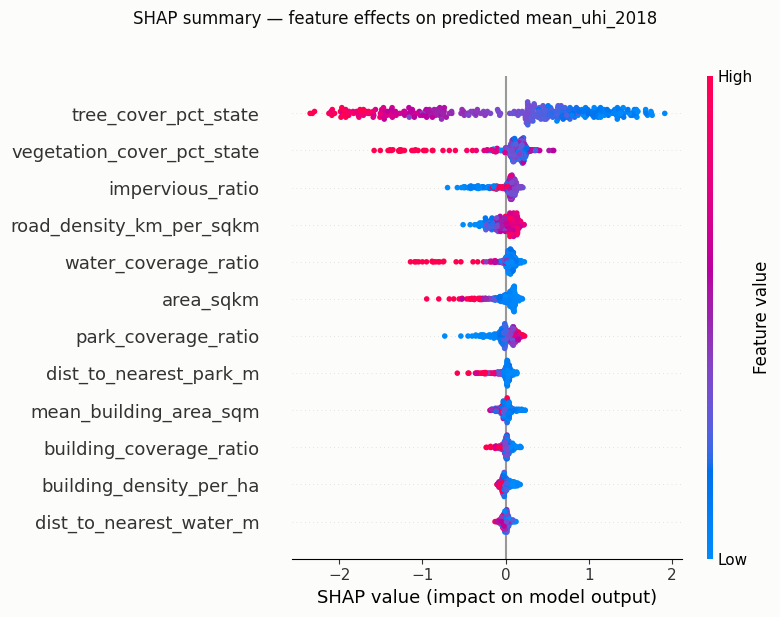

saved: F:\personal_documents\Study\urbancool_melbourne\urbancool_melbourne\models\shap_summary.png


In [5]:
shap.summary_plot(explanation, X_imputed, show=False)
fig = plt.gcf()
fig.set_size_inches(8, 6)
fig.suptitle("SHAP summary — feature effects on predicted mean_uhi_2018", y=1.02)
fig.tight_layout()

models_dir = PROJECT_ROOT / config["paths"]["models"]
fig.savefig(models_dir / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved:", models_dir / "shap_summary.png")

## 4. Global importance — mean |SHAP value|

A bar-chart alternative to the beeswarm: average magnitude of each feature's effect,
ignoring direction. Compare this to the impurity-based `feature_importances_` bar chart
in `03_model_training.ipynb` section 7 — they're computed completely differently
(Shapley game-theoretic attribution vs. impurity reduction) but should broadly agree on
which features matter most, which is a useful cross-check.

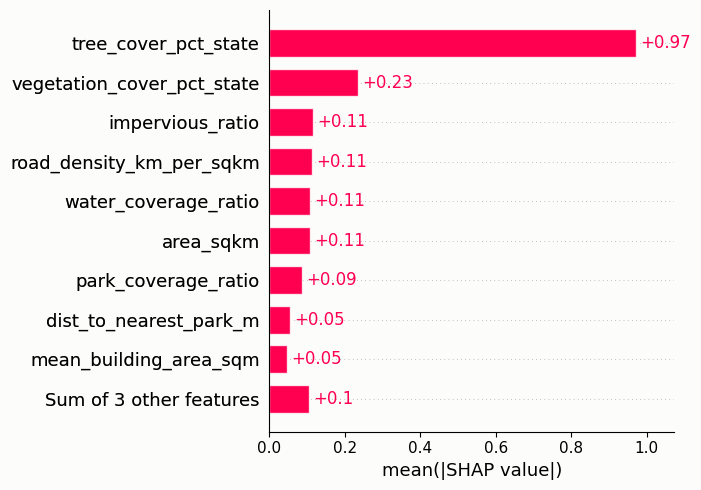

In [6]:
shap.plots.bar(explanation, show=False)
fig = plt.gcf()
fig.set_size_inches(7, 5)
fig.tight_layout()
plt.show()

In [7]:
mean_abs_shap = pd.DataFrame({
    "feature": FEATURE_COLS,
    "mean_abs_shap": np.abs(explanation.values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

impurity_importance = pd.read_csv(models_dir / "feature_importance.csv").rename(columns={"importance": "impurity_importance"})

comparison = mean_abs_shap.merge(impurity_importance, on="feature")
comparison["shap_rank"] = comparison["mean_abs_shap"].rank(ascending=False).astype(int)
comparison["impurity_rank"] = comparison["impurity_importance"].rank(ascending=False).astype(int)
comparison.sort_values("shap_rank")

,feature,mean_abs_shap,impurity_importance,shap_rank,impurity_rank
0,tree_cover_pct_state,0.973106,0.414992,1,1
1,vegetation_cover_pct_state,0.234307,0.180671,2,2
2,impervious_ratio,0.114995,0.063694,3,3
3,road_density_km_per_sqkm,0.113199,0.047750,4,6
4,water_coverage_ratio,0.108033,0.054847,5,5
5,area_sqkm,0.106392,0.058035,6,4
6,park_coverage_ratio,0.085372,0.046771,7,7
7,dist_to_nearest_park_m,0.054125,0.032732,8,8
8,mean_building_area_sqm,0.046682,0.031626,9,9
9,building_coverage_ratio,0.039497,0.025337,10,10


## 5. Dependence plots — how does the effect change with the feature's value?

The summary plot shows *that* `tree_cover_pct_state` matters most; a dependence plot
shows *how* — is the cooling effect linear, or does it saturate? SHAP auto-picks a
colouring feature to reveal interactions; here we show the three highest-ranked features
from section 4.

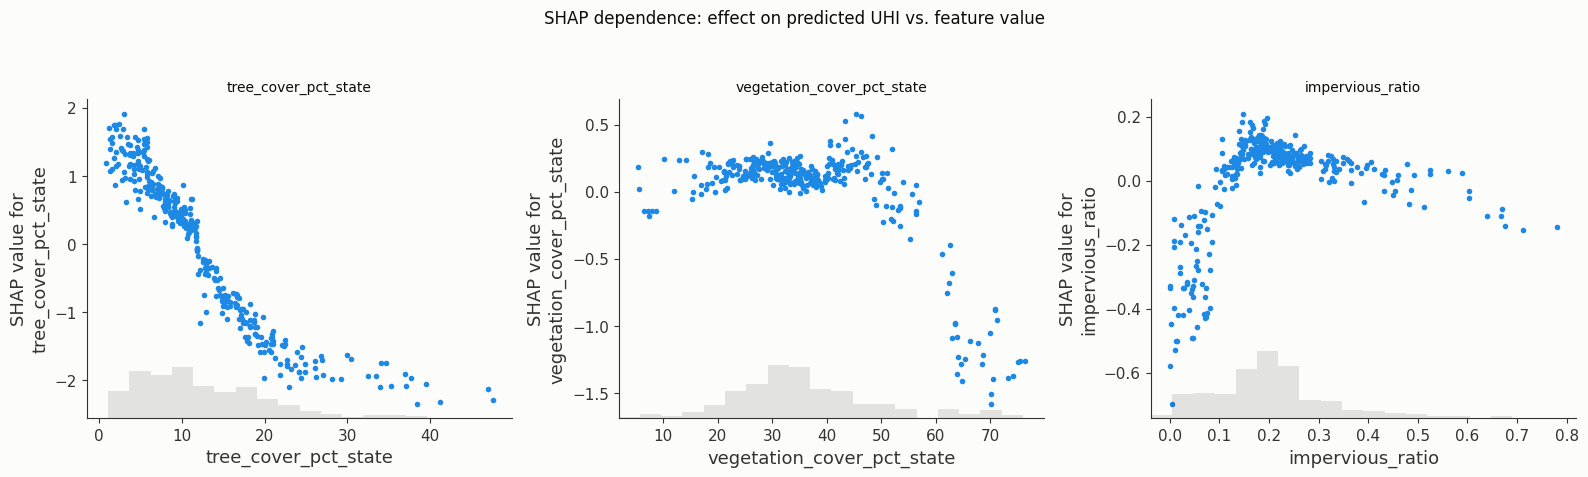

In [8]:
top_features = mean_abs_shap["feature"].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, feat in zip(axes, top_features):
    shap.plots.scatter(explanation[:, feat], ax=ax, show=False)
    ax.set_title(feat, fontsize=10)
fig.suptitle("SHAP dependence: effect on predicted UHI vs. feature value", y=1.05)
fig.tight_layout()
plt.show()

## 6. One prediction, explained

A waterfall plot for a single SA2 — concretely showing how SHAP attributes an individual
prediction, not just the aggregate patterns above. Picked here: the SA2 with the single
highest predicted UHI.

Hottest predicted SA2: Cranbourne North - East (predicted 11.50 °C)


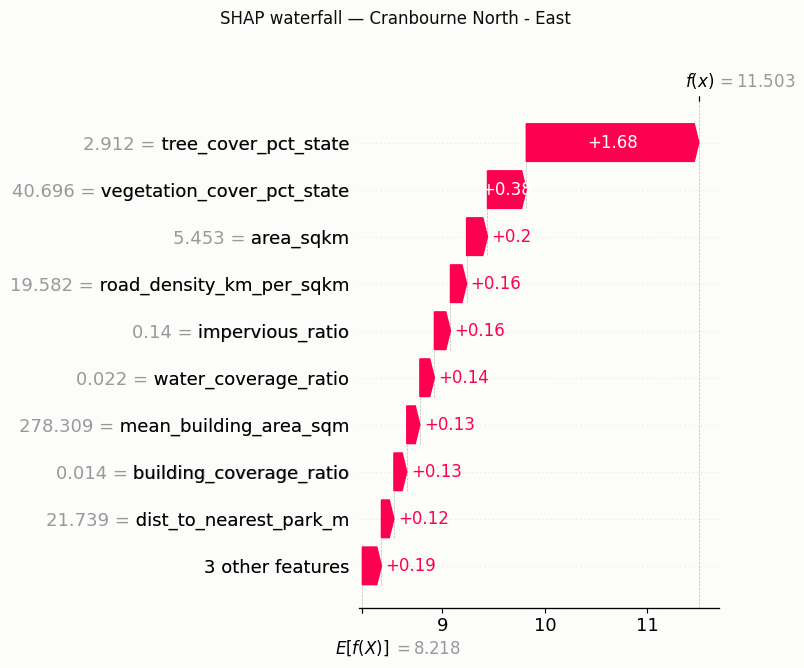

In [9]:
hottest_idx = model.predict(X).argmax()
hottest_name = data.iloc[hottest_idx]["SA2_NAME21"]
print(f"Hottest predicted SA2: {hottest_name} (predicted {model.predict(X)[hottest_idx]:.2f} °C)")

shap.plots.waterfall(explanation[hottest_idx], show=False)
fig = plt.gcf()
fig.suptitle(f"SHAP waterfall — {hottest_name}", y=1.02)
fig.tight_layout()
plt.show()

## Takeaways

- **The SHAP values exactly reconstruct the model's predictions** (section 2's assertion
  passed) — confirms the explainer is wired up correctly against this specific saved
  model, not silently explaining a different one.
- **Vegetation dominates**: `tree_cover_pct_state` and `vegetation_cover_pct_state`
  together account for the large majority of mean |SHAP value|, agreeing with both the
  impurity-based feature importance in `03_model_training.ipynb` and the raw correlations
  in `02_feature_engineering.ipynb` — three independent methods pointing the same
  direction is a good sign the signal is real, not an artifact of one particular
  technique.
- **The dependence plot for `tree_cover_pct_state` shows a steep effect at low cover and
  a flatter one at high cover** — consistent with a saturating (non-linear) cooling
  effect, which is exactly the kind of relationship a linear model (Ridge) structurally
  cannot represent, explaining Ridge's weaker CV performance in `03_model_training.ipynb`.
- `models/shap_summary.png` is saved as the deliverable PNG per the project guide.

See `DAY_4.md` for the conceptual explanation of Shapley values and the full write-up.